In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import shap

df = pd.read_csv('./data/cleaned_data.csv')

C:\Users\vecto\AppData\Local\Temp\ipykernel_29100\2978554241.py:8: DtypeWarning: Columns (0: verification_status_joint, 1: sec_app_earliest_cr_line) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('./data/cleaned_data.csv')


In [2]:
print(df['issue_d'].min(), df['issue_d'].max())

2007-06-01 2018-12-01


Set up train-test split:

In [3]:
df['issue_d'] = pd.to_datetime(df['issue_d'])
categorical_cols = ['purpose', 'home_ownership', 'verification_status']
for col in categorical_cols:
    df[col] = df[col].astype('category')

In [4]:
split_date = pd.Timestamp('2017-01-01')
train = df[df['issue_d'] < split_date]
test = df[df['issue_d'] >= split_date]
print(train.shape, test.shape)

(1321847, 102) (938821, 102)


In [5]:
features = [
    'loan_amnt', 'term', 'purpose', 'emp_length', 'home_ownership',
    'annual_inc', 'verification_status', 'dti', 'delinq_2yrs',
    'fico_range_low', 'fico_range_high', 'inq_last_6mths',
    'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
    'mort_acc', 'credit_history_months'
]

X_train = train.drop(columns=['int_rate', 'issue_d'])[features]
y_train = train['int_rate']
X_test = test.drop(columns=['int_rate', 'issue_d'])[features]
y_test = test['int_rate']

Fit a LightGBM model:

In [6]:
model = lgb.LGBMRegressor(random_state=42)
model.fit(X_train, y_train, categorical_feature=categorical_cols)

preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.023933 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1902
[LightGBM] [Info] Number of data points in the train set: 1321847, number of used features: 19
[LightGBM] [Info] Start training from score 13.178320


In [13]:
print(f'MAE: {mae:.4f}, RMSE: {rmse:.4f}')

MAE: 2.9826, RMSE: 4.0265


Compare RMSE/MAE against interest rate:

In [7]:
print(y_test.describe())

count    938821.000000
mean         12.972459
std           5.175132
min           5.310000
25%           9.440000
50%          11.990000
75%          15.990000
max          30.990000
Name: int_rate, dtype: float64


Look at feature importance:

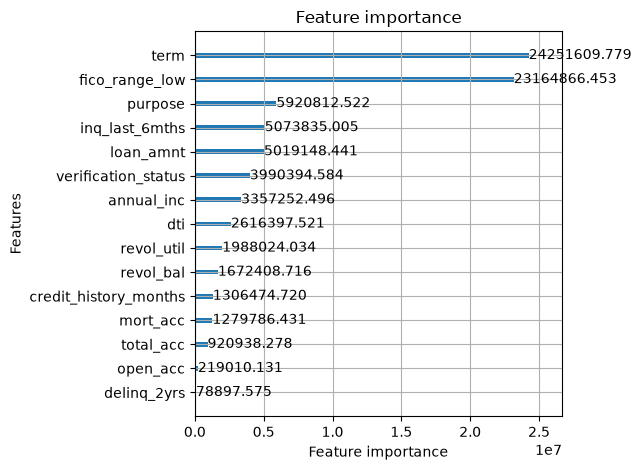

In [8]:
import matplotlib.pyplot as plt
lgb.plot_importance(model, max_num_features=15, importance_type='gain')
plt.tight_layout()
plt.show()

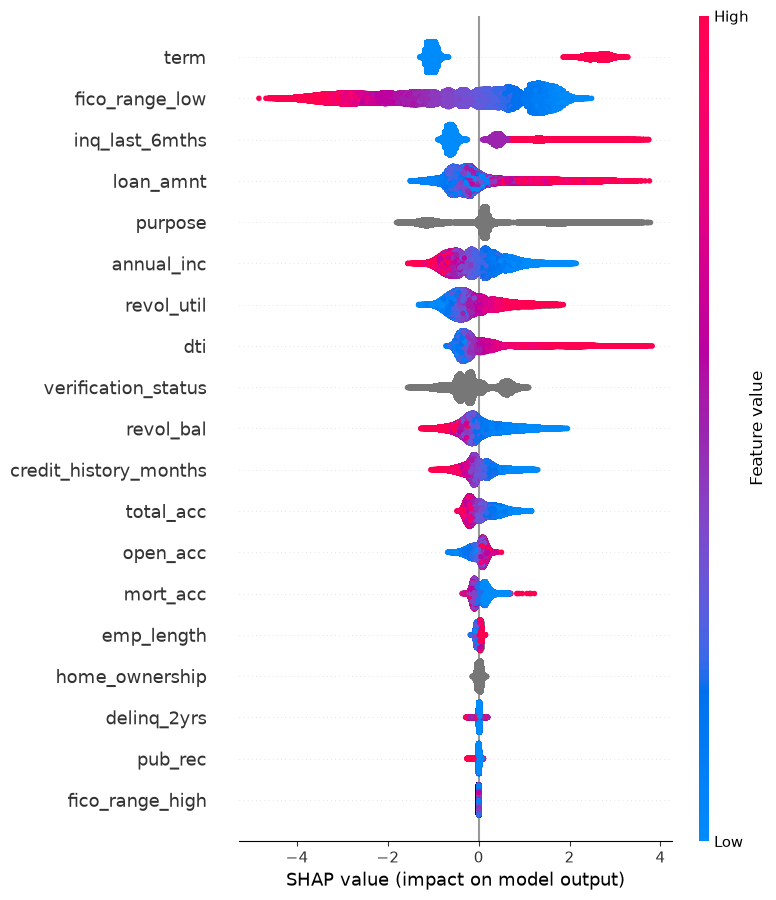

In [9]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

Feature engineering:

In [10]:
train['loan_to_income'] = train['loan_amnt'] / (train['annual_inc'] + 1)
test['loan_to_income'] = test['loan_amnt'] / (test['annual_inc'] + 1)

train['revol_bal_to_income'] = train['revol_bal'] / (train['annual_inc'] + 1)
test['revol_bal_to_income'] = test['revol_bal'] / (test['annual_inc'] + 1)

train['util_per_account'] = train['revol_util'] / (train['open_acc'] + 1)
test['util_per_account'] = test['revol_util'] / (test['open_acc'] + 1)

# Add new features to your feature list
features_v2 = features + ['loan_to_income', 'revol_bal_to_income', 'util_per_account']

X_train = train[features_v2].copy()
X_test = test[features_v2].copy()
for col in categorical_cols:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

In [11]:
model2 = lgb.LGBMRegressor(random_state=42)
model2.fit(X_train, y_train, categorical_feature=categorical_cols)

preds2 = model2.predict(X_test)

mae2 = mean_absolute_error(y_test, preds2)
rmse2 = np.sqrt(mean_squared_error(y_test, preds2))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.040846 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2667
[LightGBM] [Info] Number of data points in the train set: 1321847, number of used features: 22
[LightGBM] [Info] Start training from score 13.178320


In [14]:
print(f'MAE: {mae2:.4f}, RMSE: {rmse2:.4f}')

MAE: 2.9723, RMSE: 4.0213


Additional features had a marginal impact on MAE and RMSE

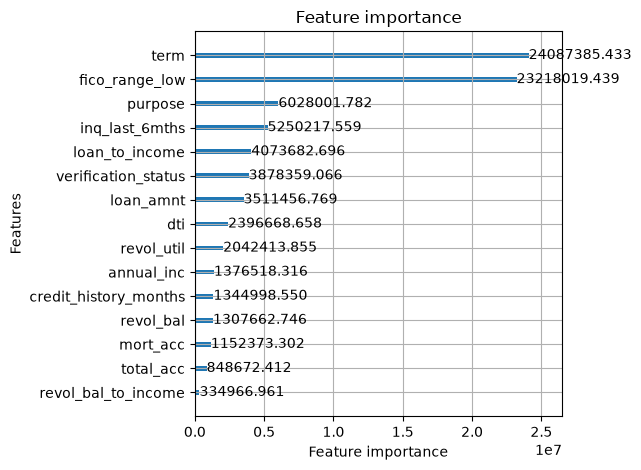

In [15]:
import matplotlib.pyplot as plt
lgb.plot_importance(model2, max_num_features=15, importance_type='gain')
plt.tight_layout()
plt.show()

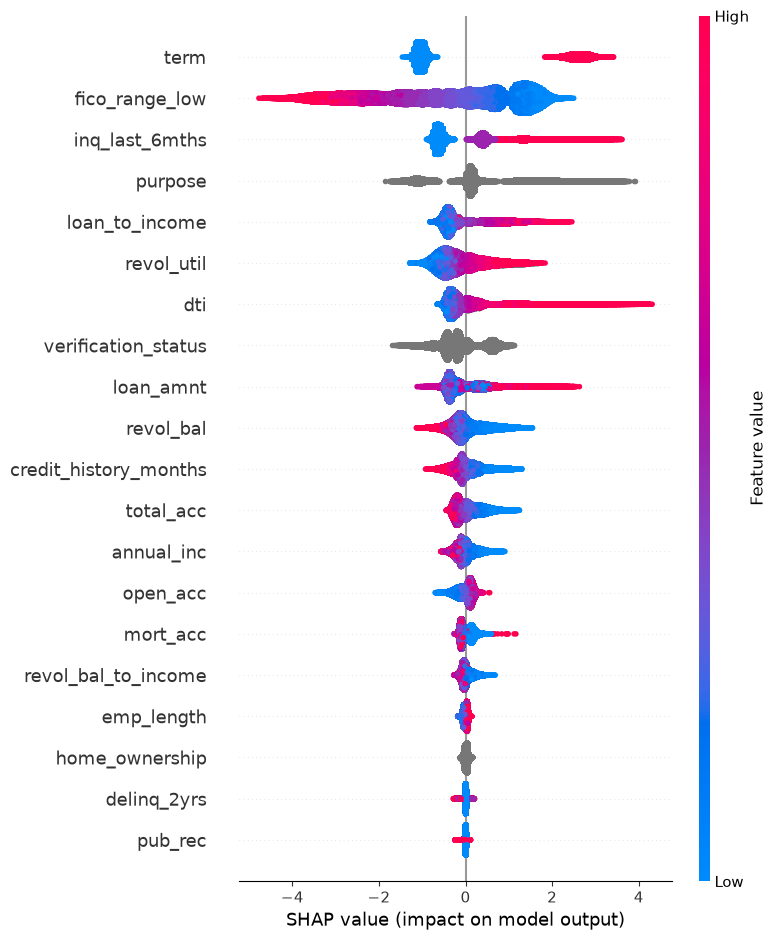

In [16]:
explainer = shap.TreeExplainer(model2)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

Early stopping:

In [21]:
model3 = lgb.LGBMRegressor(random_state=42, n_estimators=1000)
model3.fit(X_train, y_train, categorical_feature=categorical_cols,
          eval_set=[(X_test, y_test)], callbacks=[lgb.early_stopping(50)])

preds3 = model3.predict(X_test)
mae3 = mean_absolute_error(y_test, preds3)
rmse3 = np.sqrt(mean_squared_error(y_test, preds3))

f:\Stuff\School\UWaterloo\spring 2026\stat 444\Final Project\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.021419 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2667
[LightGBM] [Info] Number of data points in the train set: 1321847, number of used features: 22
[LightGBM] [Info] Start training from score 13.178320
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[384]	valid_0's l2: 16.0945


In [22]:
print("MAE:", mae3, "RMSE:", rmse3)

MAE: 2.959122804620634 RMSE: 4.011800453118366


Early stopping again has a marginal effect on MAE and RMSE.

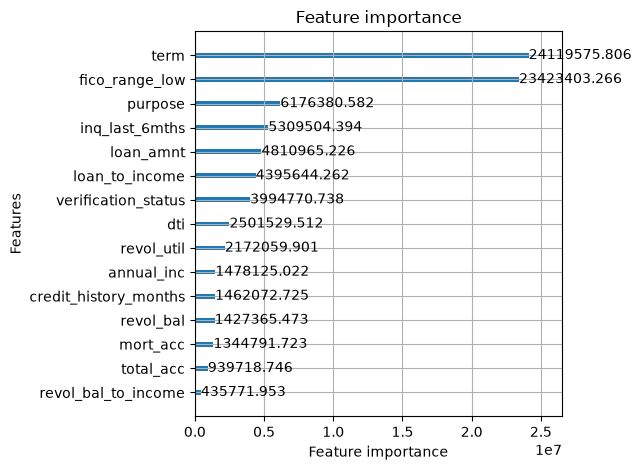

In [23]:
import matplotlib.pyplot as plt
lgb.plot_importance(model3, max_num_features=15, importance_type='gain')
plt.tight_layout()
plt.show()

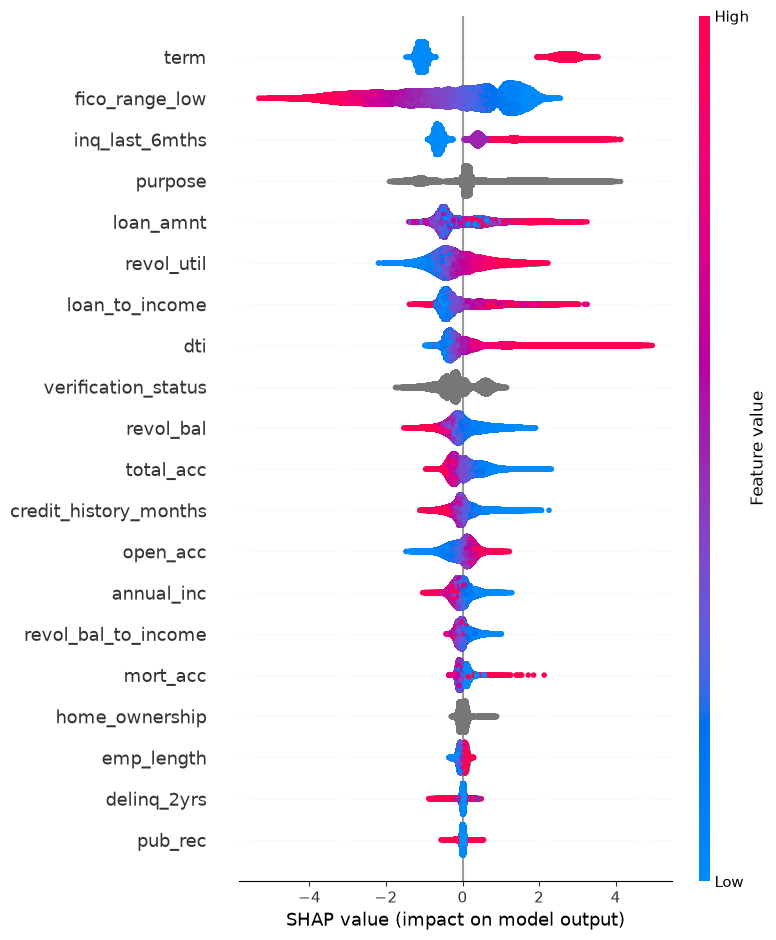

In [24]:
explainer = shap.TreeExplainer(model3)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

Residual plot of the final model:

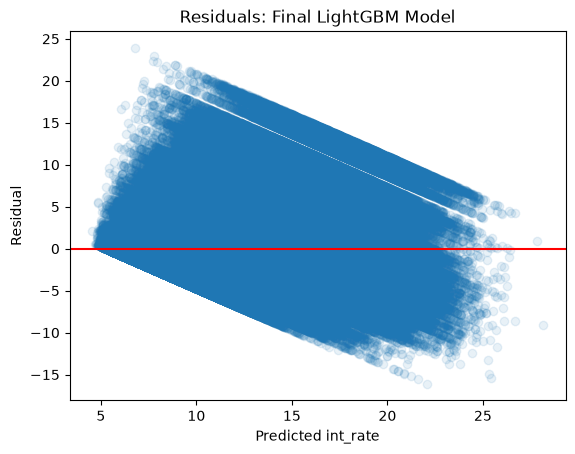

In [26]:
residuals = y_test - preds3
plt.scatter(preds3, residuals, alpha=0.1)
plt.axhline(0, color='red')
plt.xlabel('Predicted int_rate')
plt.ylabel('Residual')
plt.title('Residuals: Final LightGBM Model')
plt.show()

Compare to a baseline linear regression model:

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

numeric_cols = [c for c in features_v2 if c not in categorical_cols]

preprocessor = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), numeric_cols),
    ('cat', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_cols)
])

lr_pipeline = Pipeline([('prep', preprocessor), ('lr', LinearRegression())])
lr_pipeline.fit(X_train.astype({c: 'object' for c in categorical_cols}), y_train)
lr_preds = lr_pipeline.predict(X_test.astype({c: 'object' for c in categorical_cols}))

lr_mae = mean_absolute_error(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
print("MAE:", lr_mae, "RMSE:", lr_rmse)

MAE: 3.0661136121572894 RMSE: 4.218904628992903
